<font size="6" color='grey'> <b>
Machine Learning
</b></font> </br>

<font size="5" color='grey'> <b>
Unsupervised Learning - Isolation Forest - Network-Intrusion-Detektor
</b></font> </br>

---

# 0  | Install & Import
***

In [1]:
# Install

In [2]:
# Daten
from pandas import read_csv, DataFrame, concat

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Modell (Anomalie-Erkennung)
from sklearn.ensemble import IsolationForest

# Modell (Klassifikation / Split)
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Visualisierung
import plotly.express as px
import plotly.subplots as sp
import matplotlib.pyplot as plt

In [3]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# 1  | Understand
***

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

Dies ist der Datensatz, der für den Third International Knowledge Discovery and Data Mining Tools Competition verwendet wurde. Die Wettbewerbsaufgabe bestand darin, einen Netzwerk-Intrusion-Detektor zu bauen, ein Vorhersagemodell, das in der Lage ist, zwischen schlechten Verbindungen, sogenannten Intrusionen oder Angriffen, und guten normalen Verbindungen zu unterscheiden. Diese Datenbank enthält einen zu prüfenden Standarddatensatz, der eine Vielzahl von Eindringversuchen umfasst, die in einer militärischen Netzwerkumgebung simuliert wurden.

Der ursprüngliche KDD Cup 1999-Datensatz aus dem UCI-Repositorium für maschinelles Lernen enthält 41 Attribute (34 kontinuierlich und 7 kategorial), sie werden jedoch auf 3 Attribute (Dauer, src_bytes, dst_bytes) reduziert.

Da die kontinuierlichen Attributwerte um '0' herum konzentriert sind, haben wir jeden Wert durch y = log(x + 0,1) in einen Wert weit von '0' transformiert.

Aus KDD Cup 1999-Datensatz werden ca. 500k "http"-Dienstdaten verwendet.

[DataSet](https://www.openml.org/search?type=data&status=active&id=1113)

[Info](http://odds.cs.stonybrook.edu/http-kddcup99-dataset/)

[UCI](https://archive.ics.uci.edu/ml/datasets/kdd+cup+1999+data)

[KDD](https://kdd.org/kdd-cup)


**Datensatz:**

| feature name  | description                                      | type        |
|------------|--------------------------------------------------|-------------|
| duration   | length (number of seconds) of the connection     | continuous  |
| src_bytes  | number of data bytes from source to destination  | continuous  |
| dst_bytes  | number of data bytes from destination to source  | continuous  |

<br>
<br>


In [4]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02_daten/05_tabellen/kddcup1999_xs.csv"
)

In [5]:
data = df.copy()
target = data.pop("Intrusion")

In [6]:
target.value_counts()

,count
Intrusion,
0,113058
1,442


# 2 | Prepare

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Datentyp ermitteln/ändern</br>
✅ Train-Test-Split durchführen</br>
✅ Nicht benötigte Features löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorische Features Kodieren</br>
✅ Numerische Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>

 <p><font color='black' size="5">
Train-Test-Split (nur zur Reduktion des Datenvolumens)
</font></p>

Erfolgt nur, um das Datenvolumen zu reduzieren. Bei 100k Datensätze erfolgt Abbruch mit Hinweis auf Bezahlversion. 😉

In [7]:
data, _, target, _ = train_test_split(data, target, train_size=0.5, random_state=42, stratify=target)
data.shape, target.shape

((56750, 3), (56750,))

In [8]:
target.value_counts()

,count
Intrusion,
0,56529
1,221


# 3 | Modeling
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">🟠 Algorithmus: Isolation Forest</font></p>

Isolation Forest erkennt Anomalien durch gezieltes Isolieren einzelner Datenpunkte. Das Modell baut viele zufällige Entscheidungsbäume (Isolation Trees) auf. Datenpunkte, die schon mit wenigen Splits isoliert werden können, sind weit von der Hauptdatenwolke entfernt — und damit Anomalien.

**Analogie:** Um ein einzelnes verlorenes Schaf in einer Herde zu finden, braucht man nur wenige Zäune. Das Schaf zu isolieren, das mitten in der Herde steht, erfordert viel mehr Trennungen.

**Wichtige Parameter:**

| Parameter | Bedeutung |
|-----------|----------|
| `n_estimators` | Anzahl Isolation Trees (mehr = stabiler, aber langsamer) |
| `contamination` | Erwarteter Ausreißer-Anteil — steuert den Entscheidungsschwellenwert |
| `max_samples` | Stichprobengröße pro Baum (default: min(256, n)) |
| `random_state` | Reproduzierbarkeit |
| Ausgabe sklearn | 1 = Inlier (normal), -1 = Outlier (Anomalie) |

**In der Praxis relevant wenn:**
- Anomalien als kompakter Cluster vorliegen — Isolation Forest isoliert Cluster-Ausreißer, LOF versagt hier
- Hochdimensionale Daten vorliegen — Isolation Forest skaliert besser als dichtebasierte Methoden
- Schnelles Training gefragt ist — Baummodelle sind effizient auch bei großen Datensätzen

**Grenze:**
Wenn Anomalien in der Datenmitte liegen (Anomalien ähneln strukturell Normaldaten), kann Isolation Forest sie ebenfalls nicht erkennen. In diesem Fall ist One-Class SVM zu prüfen.

**Typischer Fehler:**
`contamination` ohne Blick auf die tatsächliche Klassenverteilung belassen. Nach `target.value_counts()` die Anomalierate ablesen und `contamination` entsprechend anpassen.

In [9]:
#@markdown   <p><font size="4" color='green'>  Isolation Forest – Isolations-Prinzip</font> </br></p>

import base64
from IPython.display import Image, display

diagram = """
flowchart TD
    DATA[Datenpunkte] --> SAMPLE[Zufaellige Teilmenge auswaehlen]
    SAMPLE --> TREE[Isolation Tree aufbauen]
    TREE --> PATH[Pfadlaenge zur Isolation messen]
    PATH --> AVG[Durchschnitt ueber alle Baeume]
    AVG --> CHECK{Kurze Pfadlaenge?}
    CHECK -->|ja| OUTLIER[Outlier - Anomalie]
    CHECK -->|nein| INLIER[Inlier - Normal]
"""

encoded = base64.urlsafe_b64encode(diagram.strip().encode()).decode()
display(Image(url=f"https://mermaid.ink/img/{encoded}", width=450))

 <p><font color='black' size="5">
Modellauswahl & Training
</font></p>

In [10]:
model = IsolationForest(n_estimators=200, max_samples=256, random_state=42)

In [11]:
model.fit(data)

IsolationForest(max_samples=256, n_estimators=200, random_state=42)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Schwellenwert automatisch ermitteln (KDE)
</font></p>

In [25]:
import numpy as np
from scipy.stats import gaussian_kde
from scipy.signal import argrelmin

# Anomalie-Scores berechnen
scores = model.decision_function(data)

# KDE über Scores
x = np.linspace(scores.min(), scores.max(), 1000)
kde = gaussian_kde(scores, bw_method=0.3)
density = kde(x)

# Lokales Minimum = natürlicher Schwellenwert
minima_idx = argrelmin(density, order=30)[0]
threshold = x[minima_idx[0]] if len(minima_idx) > 0 else 0.0
print(f"Schwellenwert: {threshold:.4f}")

# Visualisierung KDE + Schwellenwert
fig = px.line(
    x=x, y=density,
    title=f"Score-Verteilung (KDE) | Schwellenwert: {threshold:.4f}",
    labels={"x": "Anomalie-Score", "y": "Dichte"},
    width=700, height=400,
)
fig.add_vline(x=threshold, line_dash="dash", line_color="red",
              annotation_text="Schwellenwert")
fig.show()

# Klassifikation mit automatischem Schwellenwert (label-frei)
labels_auto = np.where(scores < threshold, -1, 1)
DataFrame({"Label": labels_auto}).value_counts()

Schwellenwert: -0.2107


,count
Label,
1,56477
-1,273


In [26]:
# Anomalie-Scores nach Kategorie (Inlier / Outlier)
score_df = DataFrame({"Anomalie_Score": scores, "Label": labels_auto})
score_df["Kategorie"] = score_df["Label"].map({1: "Inlier", -1: "Outlier"})

fig = px.histogram(
    score_df,
    x="Anomalie_Score",
    color="Kategorie",
    nbins=100,
    title="Verteilung Anomalie-Scores (Isolation Forest)",
    labels={"Anomalie_Score": "Score (negativ = Anomalie)", "count": "Anzahl"},
    width=700,
    height=450,
)
fig.add_vline(x=threshold, line_dash="dash", line_color="red",
              annotation_text="Schwellenwert")
fig.show()

<p><font color='black' size="5">
Umkodierung Ergebnisse Isolation Forest
</font></p>

In [14]:
target_pred = DataFrame(labels_auto).copy()
target_pred.columns = ["Intrusion"]
# Isolation Forest: -1 = Outlier (Anomalie) -> 1 = Intrusion ja
#                    1 = Inlier  (Normal)   -> 0 = Intrusion nein
target_pred.replace([-1, 1], [1, 0], inplace=True)

In [15]:
target_pred.value_counts()

,count
Intrusion,
0,56477
1,273



<p><font color='black' size="5">
Confusion Matrix
</font></p>

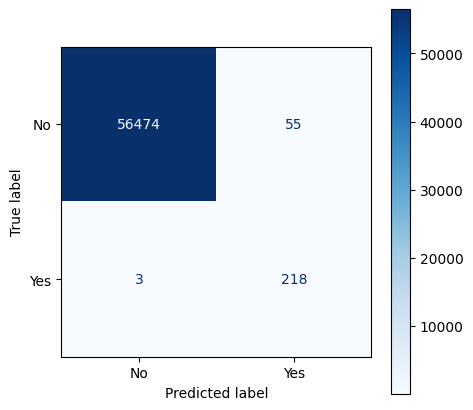

In [16]:
conf_matrix = confusion_matrix(target, target_pred["Intrusion"])
plt.rcParams["figure.figsize"] = [5, 5]
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=["No", "Yes"])
disp.plot(cmap="Blues")

In [17]:
print(classification_report(target, target_pred["Intrusion"], target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00     56529
         Yes       0.80      0.99      0.88       221

    accuracy                           1.00     56750
   macro avg       0.90      0.99      0.94     56750
weighted avg       1.00      1.00      1.00     56750



<p><font color='black' size="5">
Aufbau Analysewürfel
</font></p>

In [18]:
# Übernahme der Testdaten
cube = data.copy()
cube.reset_index(inplace=True)

# Übernahme Target real & predict
cube["real"] = target.values
cube["predict"] = target_pred["Intrusion"].values
cube["scores"] = scores

In [19]:
# Erstellung 2D Features über Dimensionsreduktion PCA - unsupervised
pca = PCA(n_components=2)
pca = pca.fit_transform(data)
pca_df = DataFrame(pca)

# Cube um pca erweitern
cube["PCA1"] = pca_df[0]
cube["PCA2"] = pca_df[1]

<p><font color='black' size="5">
Visualisierung real vs predict
</font></p>

In [20]:
# Histogramm
title_ = "Histogramm real vs predict"
fig = px.histogram(cube, x=["real", "predict"], nbins=2, text_auto=".2s", title=title_)
fig.update_layout(barmode="group", bargap=0.1, width=600, height=600)
fig.show()

In [21]:
# 2 x Scatterplots

cube["real_cat"] = cube["real"].astype(str)
cube["predict_cat"] = cube["predict"].astype(str)

img1 = px.scatter(cube, x="PCA1", y="PCA2", color="real_cat", width=600, height=600)
img2 = px.scatter(cube, x="PCA1", y="PCA2", color="predict_cat", width=600, height=600)

fig = sp.make_subplots(
    rows=1, cols=2, subplot_titles=("Scatterplot real", "Scatterplot predict")
)

for trace in img1.data:
    fig.add_trace(trace, row=1, col=1)
for trace in img2.data:
    fig.add_trace(trace, row=1, col=2)

fig.update_layout(width=1000, height=500, title_text="Streupunktdiagramm real vs predict")
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [22]:
cube[cube.real != cube.predict]

,index,duration,src_bytes,dst_bytes,real,predict,scores,PCA1,PCA2,real_cat,predict_cat
84,320674,-2.302585,-2.302585,-2.302585,0,1,-0.234745,-10.023840,-1.167270,0,1
385,526280,-2.302585,-2.302585,-2.302585,0,1,-0.234745,-10.023840,-1.167270,0,1
1557,174991,4.191169,5.700778,4.852811,0,1,-0.213204,-2.835640,6.360698,0,1
2913,388383,-2.302585,-2.302585,-2.302585,0,1,-0.234745,-10.023840,-1.167270,0,1
5494,453071,-2.302585,-2.302585,-2.302585,0,1,-0.234745,-10.023840,-1.167270,0,1
5522,388118,5.031091,5.652840,5.153869,0,1,-0.213876,-2.563173,7.198594,0,1
5962,410552,5.031091,5.323498,5.231643,0,1,-0.212300,-2.495648,7.164899,0,1
6383,12268,5.736895,5.694069,4.852811,0,1,-0.225234,-2.885193,7.895855,0,1
8671,342740,-2.302585,-2.302585,-2.302585,0,1,-0.234745,-10.023840,-1.167270,0,1
9840,541763,-2.302585,-2.302585,-2.302585,0,1,-0.234745,-10.023840,-1.167270,0,1


# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>